In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/titanic-dataset


In [3]:
df = pd.read_csv(path + "/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.drop('PassengerId',axis = 1,inplace = True)

In [5]:
df.drop('Name',axis = 1,inplace = True)

In [6]:
df.drop('Ticket',axis = 1,inplace = True) #At fisrt glimpse I consider that this columns are useless

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [8]:
df.drop('Embarked',axis = 1,inplace = True)

In [9]:
df.drop('Cabin',axis = 1,inplace = True) #These columns also (feature Extraction DONE)

In [10]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000
887,1,1,female,19.0,0,0,30.0000
888,0,3,female,NaN,1,2,23.4500
889,1,1,male,26.0,0,0,30.0000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 48.9+ KB


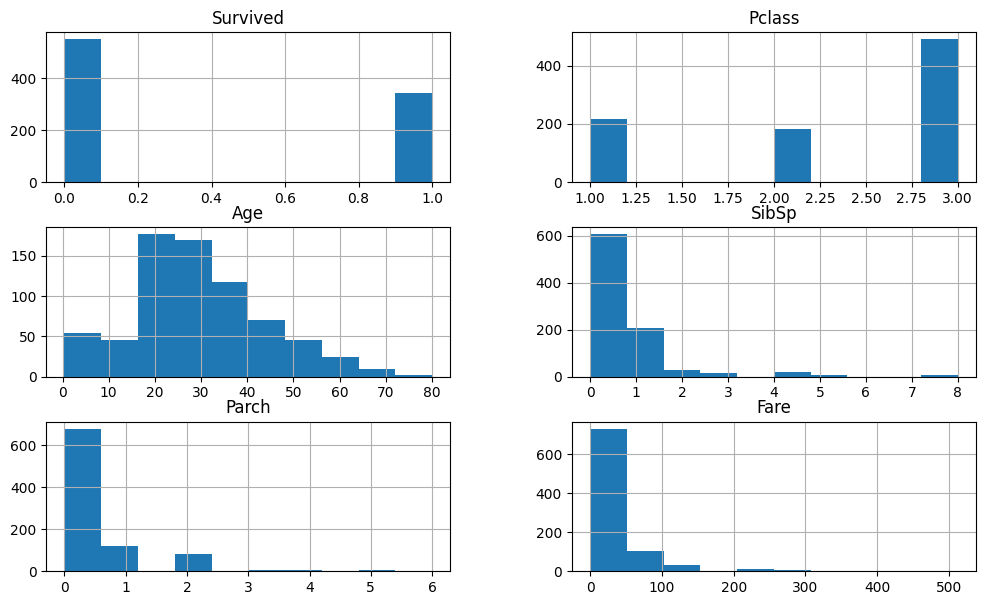

In [12]:
df.hist(figsize =(12,7));

In [13]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0


<Axes: >

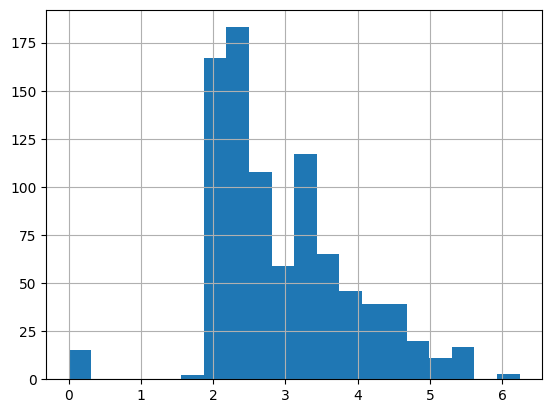

In [14]:
import numpy as np
df["Fare"].apply(lambda x: np.log(x+1)).hist(bins=20) #For get rid of outliers i aplied log transformation to Fare column(testing)

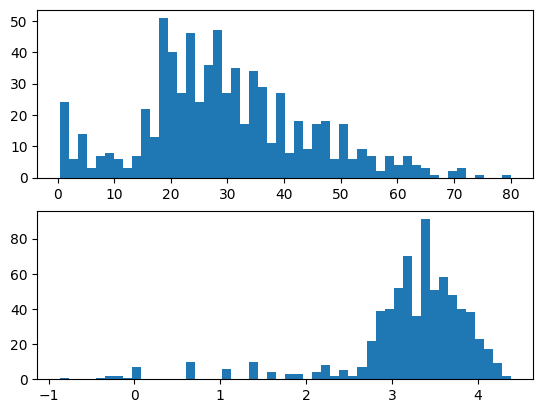

In [15]:
import numpy as np
plt.subplot(2,1,1)
plt.hist(df['Age'], bins =50 )
plt.subplot(2,1,2)
plt.hist(np.log(df['Age']), bins = 50 ); #Also for Age column(testing)

In [16]:
df.corr(numeric_only = True)['Survived'].sort_values(ascending = False)
#Here you can see that Fare column have directly correlation with Survived column

,Survived
Survived,1.000000
Fare,0.257307
Parch,0.081629
SibSp,-0.035322
Age,-0.077221
Pclass,-0.338481


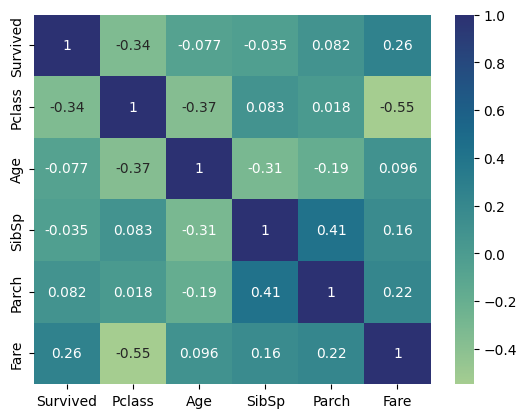

In [17]:
import seaborn as sns
x = df.corr(numeric_only = True)

sns.heatmap(x, annot=True, cmap='crest')

plt.show()

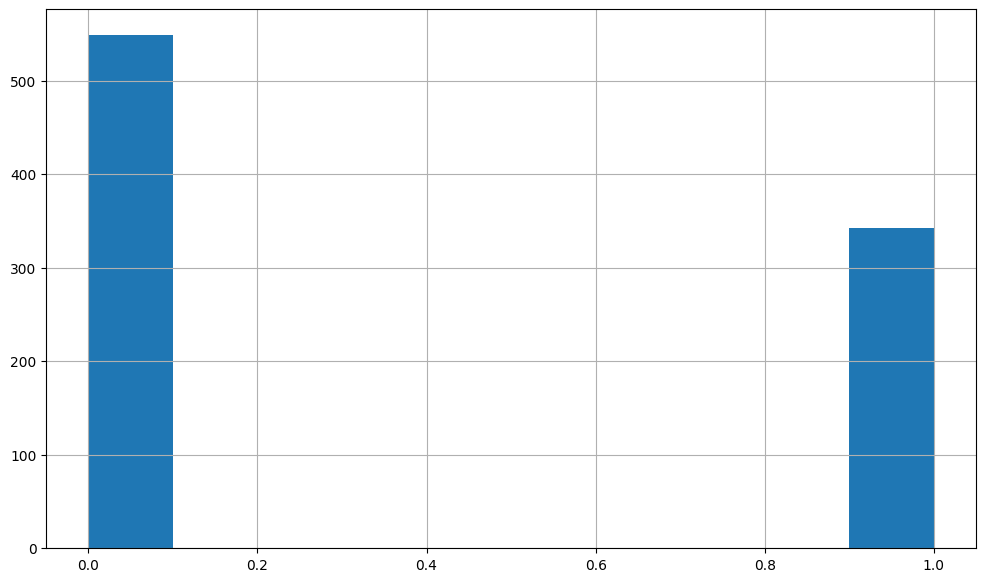

In [18]:
df["Survived"].hist(figsize =(12,7));


In [19]:
print((df["Survived"] == 1).sum())
print((df["Survived"] == 0).sum())
# I saw this part after end of my course in DIV academy and try to change this model can tolarateto skewed(inbalance) dataset

342
549


In [20]:
from sklearn.model_selection import train_test_split
X = df.drop('Survived', axis = 1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42)

In [21]:
X_num = X_train.select_dtypes(include = np.number)
X_cat = X_train.select_dtypes(include = 'object')
X_num

,Pclass,Age,SibSp,Parch,Fare
331,1,45.5,0,0,28.5000
733,2,23.0,0,0,13.0000
382,3,32.0,0,0,7.9250
704,3,26.0,1,0,7.8542
813,3,6.0,4,2,31.2750
...,...,...,...,...,...
106,3,21.0,0,0,7.6500
270,1,NaN,0,0,31.0000
860,3,41.0,2,0,14.1083
435,1,14.0,1,2,120.0000


In [22]:
X_num = X_train.select_dtypes(include = np.number)
X_cat = X_train.select_dtypes(include = 'object')
X_num_cols = X_train.select_dtypes(include = np.number).columns
X_cat_cols = X_train.select_dtypes(include = 'object').columns
#Dividing object and numerical features

In [23]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer


def log_transformer(X):
    return np.log(X + 1)

log_pipeline = make_pipeline(
    SimpleImputer(strategy = 'median'), # There were null values at Age column so I choosed median
    FunctionTransformer(log_transformer),
    StandardScaler()
)

X_cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'), # Optional imputer
    OrdinalEncoder()
)



X_num_pipeline = make_pipeline(
    SimpleImputer(strategy = 'median'), #Optional imputer
    StandardScaler()
)


from sklearn.compose import ColumnTransformer

transformer = ColumnTransformer([
    ('num', X_num_pipeline, X_num_cols),
    ('cat', X_cat_pipeline, X_cat_cols),
    ('log', log_pipeline, ['Age', 'Fare'])
])


In [24]:
from sklearn.linear_model import SGDClassifier #Base model
full_pipeline = make_pipeline(transformer, SGDClassifier(random_state = 42 ))
full_pipeline.fit(X_train, y_train)
full_pipeline.score(X_test, y_test)

0.7821229050279329

In [25]:
from sklearn.ensemble import RandomForestClassifier
full_pipeline = make_pipeline(transformer, RandomForestClassifier(random_state = 42, class_weight = 'balanced'))
full_pipeline.fit(X_train, y_train)
full_pipeline.score(X_test, y_test)

0.8100558659217877

In [26]:
from sklearn.ensemble import RandomForestClassifier
full_pipeline = make_pipeline(transformer, RandomForestClassifier(bootstrap = True, random_state = 42, class_weight = 'balanced'))
full_pipeline.fit(X_train, y_train)
full_pipeline.score(X_test, y_test)

0.8100558659217877

In [28]:
from sklearn.model_selection import GridSearchCV

full_pipeline = make_pipeline(
    transformer,
    RandomForestClassifier(class_weight = 'balanced' , random_state = 42)
)

param_grid = {
    'randomforestclassifier__n_estimators': [10, 20, 50, 100, 200],
    'randomforestclassifier__max_depth': [None, 5, 10, 20,30],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)


test_score = grid_search.score(X_test, y_test)
print("Test set score:", test_score)


Best parameters: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 100}
Best cross-validation score: 0.8258459501944238
Test set score: 0.8324022346368715


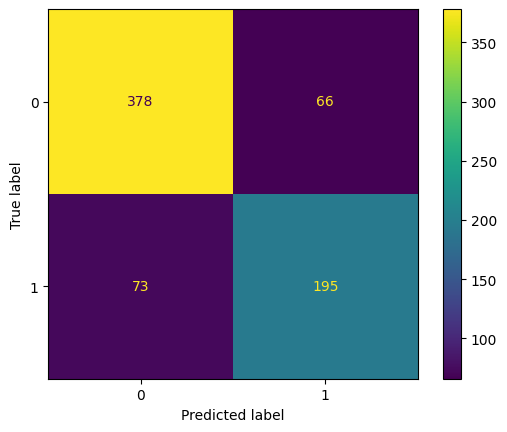

In [29]:
from sklearn.model_selection import cross_val_predict #Let's see model's predictions

y_train_pred = cross_val_predict(grid_search, X_train, y_train, cv = 3)

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"Precision: {precision_score(y_train, y_train_pred)}")
print(f"Recall: {recall_score(y_train, y_train_pred)}")
print(f"F1 Score: {f1_score(y_train, y_train_pred)}")


Precision: 0.7471264367816092
Recall: 0.7276119402985075
F1 Score: 0.7372400756143668


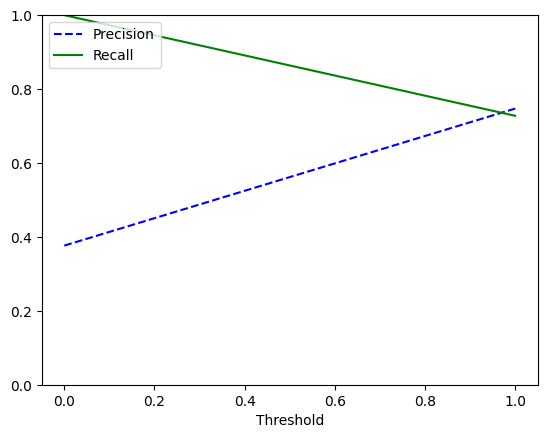

In [31]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_pred)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.legend(loc="upper left")
plt.ylim([0, 1])
plt.show()

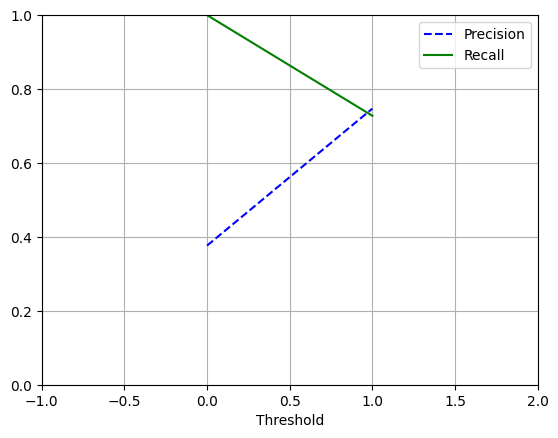

In [32]:
plt.plot(thresholds, precisions[:-1], 'b--', label = 'Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label = 'Recall')
plt.xlabel('Threshold')
plt.legend()

plt.axis([-1, 2, 0, 1])
plt.grid()
plt.show()

In [33]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train, y_train_pred)

np.float64(0.7894816458249294)

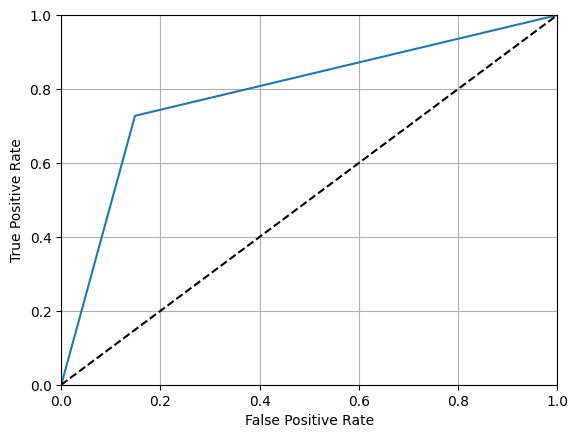

In [39]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds_roc = roc_curve(y_train, y_train_pred)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], 'k--')
plt.axis([0,1,0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.show()

In [75]:
full_pipeline = make_pipeline(transformer, RandomForestClassifier(random_state = 42, class_weight = 'balanced', max_depth = 10,
                                                                  min_samples_leaf =2 ,min_samples_split = 2, n_estimators = 100))
full_pipeline.fit(X_train, y_train)
full_pipeline.score(X_test, y_test)

0.8324022346368715

#The maximum accuracy that I can obtain is this because of lack of Data